In [3]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)

In [4]:
foldername = '/home/edavenport/analysis/yannai-waves/with_spring_2013/k_w_plots/'

In [5]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
import cmocean.cm as cmo
import xarray as xr
from open_tpose import tpose2012to2013
import numpy as np
import xarray as xr

prefix = ['diag_state','diag_surf']
ds_tpose_noTAO = tpose2012to2013(prefix)

ds_tpose_noTAO['XC'] = ds_tpose_noTAO.XC.astype(float)
ds_tpose_noTAO['YC'] = ds_tpose_noTAO.YC.astype(float)
ds_tpose_noTAO['Z'] = ds_tpose_noTAO.Z.astype(float)
ds_tpose_noTAO['XG'] = ds_tpose_noTAO.XG.astype(float)
ds_tpose_noTAO['YG'] = ds_tpose_noTAO.YG.astype(float)

from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_TAO = xr.concat([ds_tpose_TAO,ds_new],dim='time')

ds_tpose_TAO['XC'] = ds_tpose_TAO.XC.astype(float)
ds_tpose_TAO['YC'] = ds_tpose_TAO.YG.astype(float)
ds_tpose_TAO['Z'] = ds_tpose_TAO.Z.astype(float)
ds_tpose_TAO['XG'] = ds_tpose_TAO.XG.astype(float)
ds_tpose_TAO['YG'] = ds_tpose_TAO.YG.astype(float)

ds_tpose_noTAO = ds_tpose_noTAO.sel(time=slice('2012-09-01','2013-06-30'))

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


### Select Region

In [6]:
# tpose_ds.ADJetan is t, xc, YG
lat_min = -3
lat_max = 3
lon_min = 170 #170E
lon_max = 260 #100W

ds_tpose_TAO = ds_tpose_TAO.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max),XG=slice(lon_min,lon_max),YG=slice(lat_min,lat_max))
ds_tpose_noTAO = ds_tpose_noTAO.sel(XC=slice(lon_min,lon_max),YC=slice(lat_min,lat_max),XG=slice(lon_min,lon_max),YG=slice(lat_min,lat_max))

In [373]:
depth = -100
var_name = 'UVEL'
sub_folder = var_name + '/'
fig_str = var_name
lat_dim = 'YC'
lon_dim = 'XG'

### Temporal Demean and Detrend

In [374]:
from scipy.signal import detrend

vvel_noTAO_detrend = detrend(ds_tpose_noTAO[var_name], axis=0)
vvel_TAO_detrend = detrend(ds_tpose_TAO[var_name], axis=0)


# copy into data array
vvel_noTAO_detrend = xr.DataArray(vvel_noTAO_detrend, coords=ds_tpose_noTAO[var_name].coords, dims=ds_tpose_noTAO[var_name].dims)
vvel_TAO_detrend = xr.DataArray(vvel_TAO_detrend, coords=ds_tpose_TAO[var_name].coords, dims=ds_tpose_TAO[var_name].dims)

# demean
vvel_noTAO_anom = vvel_TAO_detrend - vvel_TAO_detrend.mean(dim='time')
vvel_TAO_anom = vvel_TAO_detrend - vvel_TAO_detrend.mean(dim='time')

### Filter for Desired Frequency Range

In [375]:
from scipy.signal import butter, sosfiltfilt, detrend

vvel = vvel_noTAO_anom.sel(Z=depth,method='nearest')

# filtering out high frequency changes
fs = 1/86400 # sampling rate is 1 day (86400 seconds per day)
highF = (1/3*fs) #  (1 cycle /10 days) * (1 day/86400 second)
# lowF = (1/20*fs) #  (1 cycle /30 days) * (1 day/86400 second)
# cutoff = np.array([lowF, highF])
order = 4
# sos = butter(order, cutoff, 'bandpass', fs=fs, output='sos')
sos = butter(order, highF, 'lowpass', fs=fs, output='sos')

vvel_bandpass = sosfiltfilt(sos, detrend(vvel,axis=0), axis=0)

temp = vvel.copy(deep=True)
temp.data = vvel_bandpass
vvel_bandpass = temp

vvel_bandpass = vvel_bandpass.compute()

In [376]:
# simpler: manually select +y and -y
pos = vvel_bandpass.where(vvel_bandpass[lat_dim] >= 1e-14, drop=True)
neg = vvel_bandpass.where(vvel_bandpass[lat_dim] <= 1e-13, drop=True)

# flip neg to align with pos
neg_flipped = neg.values[:,::-1,:]

# symmetric
sym = 0.5 * (pos.values + neg_flipped)
# antisymmetric
anti = 0.5 * (pos.values - neg_flipped)

vvel_bandpass_sym = xr.DataArray(sym,coords=pos.coords,dims=pos.dims)
vvel_bandpass_anti = xr.DataArray(anti,coords=pos.coords,dims=pos.dims)
vvel_bandpass_sym = vvel_bandpass_sym.mean(dim=lat_dim)
vvel_bandpass_anti = vvel_bandpass_anti.mean(dim=lat_dim)
vvel_bandpass_anom = vvel_bandpass.mean(dim=lat_dim)


#### k-w plots

In [377]:
window_t = np.hanning(vvel_bandpass_anom.shape[0])
window_x = np.hanning(vvel_bandpass_anom.shape[1])
window_2d = np.outer(window_t, window_x)
vvel_windowed = vvel_bandpass_anom * window_2d
vvel_sym_windowed = vvel_bandpass_sym * window_2d
vvel_anti_windowed = vvel_bandpass_anti * window_2d

dx = np.mean(np.diff(ds_tpose_noTAO[var_name][lon_dim]))  # in units of degrees
dt_ns = np.mean(np.diff(ds_tpose_noTAO[var_name].time))              # timedelta64[ns]
dt = dt_ns / np.timedelta64(1, 'D') # convert to float in days

print(dt)    # 1 day
print(dx)    # 1/6 degree

1.0
0.16666666666666666


In [378]:

# # -----------------------------
# # 2D FFT
# # -----------------------------
vvel_fft = np.fft.fft2(vvel_windowed)
vvel_fft = np.fft.fftshift(vvel_fft, axes=(0,1))  # shift time and lon axes
Nt = vvel_windowed.shape[0]
Nx = vvel_windowed.shape[1]
P = np.abs(vvel_fft)**2 / (Nt*Nx)

vvel_sym_fft = np.fft.fft2(vvel_sym_windowed)
vvel_sym_fft = np.fft.fftshift(vvel_sym_fft, axes=(0,1))  # shift time and lon axes
P_sym = np.abs(vvel_sym_fft)**2 / (Nt*Nx)

vvel_anti_fft = np.fft.fft2(vvel_anti_windowed)
vvel_anti_fft = np.fft.fftshift(vvel_anti_fft, axes=(0,1))  # shift time and lon axes
P_anti = np.abs(vvel_anti_fft)**2 / (Nt*Nx)

# wavenumber / frequency axes
kx = -np.fft.fftshift(np.fft.fftfreq(Nx, d=dx))        # deg^-1
omega = np.fft.fftshift(np.fft.fftfreq(Nt, d=dt)) # cycles/day


In [379]:
# -----------------------------
# Normalize for real signal
# -----------------------------
# double all non-zero, non-Nyquist frequencies along time
nonzero_idx = np.where((omega != 0) & (omega != omega.max()))[0]

# -----------------------------
# Select only positive omega
# -----------------------------
pos_idx = omega >= 0
P_pos = P[pos_idx, :]
P[nonzero_idx, :] *= 2
omega_pos = omega[pos_idx]

# Create xarray for plotting
P_da = xr.DataArray(P_pos, dims=['omega','kx'],
                    coords={'omega': omega_pos, 'kx': kx})

# -----------------------------
# Select only positive omega
# -----------------------------
P_sym[nonzero_idx, :] *= 2
P_pos = P_sym[pos_idx, :]

# Create xarray for plotting
P_da_sym = xr.DataArray(P_pos, dims=['omega','kx'],
                    coords={'omega': omega_pos, 'kx': kx})

P_anti[nonzero_idx, :] *= 2

# -----------------------------
# Select only positive omega
# -----------------------------
pos_idx = omega >= 0
P_pos = P_anti[pos_idx, :]
# Create xarray for plotting
P_da_anti = xr.DataArray(P_pos, dims=['omega','kx'],
                    coords={'omega': omega_pos, 'kx': kx})

In [380]:
# # --- Dispersion relations --- in rad/s
def omega_kelvin_fn(k, c): 
#     # Kelvin waves exist for eastward (positive k) only
    omega = np.zeros_like(k)
    omega[k>=0] = c*k[k>=0]
    omega[k<0] = np.nan  # optional: don't plot Kelvin for negative k
    return omega

def omega_yanai(k, c, beta): 
    return 0.5*(c*k - np.sqrt((c*k)**2 + 4*beta*c))

def omega_yanai_east(k, c, beta): 
    return 0.5*(c*k + np.sqrt((c*k)**2 + 4*beta*c))

def omega_rossby_fn(k, n, c, beta): 
    return - beta*k / (k**2 + (2*n + 1)*beta/c)

def omega_IG(k, n, c, beta): 
    return np.sqrt(c**2 * k**2 + (2*n + 1)*beta*c)

In [381]:
# -----------------------------
# Physical constants
# -----------------------------
g = 9.81            # m/s^2
beta = 2.3e-11      # 1/(m s)
c1 = 2.5
c2 = 1.4
deg2m = 111320      # m per degree at equator
c_barotropic = np.sqrt(9.81*4000)  # m/s

In [382]:
# deg2m = 111320      # m per degree at equator
# k_rad = 2*np.pi * kx / deg2m  # convert to rad/m

# # --- Plotting ---
# plt.figure(figsize=(6,6))

# # Kelvin (eastward only)
# plt.plot(kx, omega_kelvin_fn(k_rad, c1)*86400, label="Kelvin n=-1")

# # Yanai
# plt.plot(kx, omega_yanai(k_rad, c1, beta)*86400, label="Yanai n=0 (west)")
# plt.plot(kx, omega_yanai_east(k_rad, c1, beta)*86400, label="Yanai n=0 (east)")

# # Rossby n=1..3
# for n in [1,2,3]:
#     plt.plot(kx, omega_rossby_fn(k_rad, n, c1, beta)*86400, label=f"Rossby n={n}")

# # IG n=1..3
# for n in [1,2,3]:
#     plt.plot(kx, omega_IG(k_rad, n, c1, beta)*86400, label=f"IG n={n}")

# plt.xlabel("Zonal wavenumber k [deg$^{-1}$] (positive = east, negative = west)")
# plt.ylabel("Frequency ω [rad/day]")
# plt.title("Equatorial Wave Dispersion Curves (first baroclinic mode)")
# plt.legend()
# plt.xlim(-1, 1)
# plt.ylim(0, 1.0)
# plt.grid(True)
# plt.show()

In [387]:
from matplotlib.colors import LogNorm
min = -4
max = 0
log_levels = np.logspace(min, max, 100)
norm = LogNorm(vmin=10**min,vmax=10**max)
ticks = np.logspace(min, max, 4)

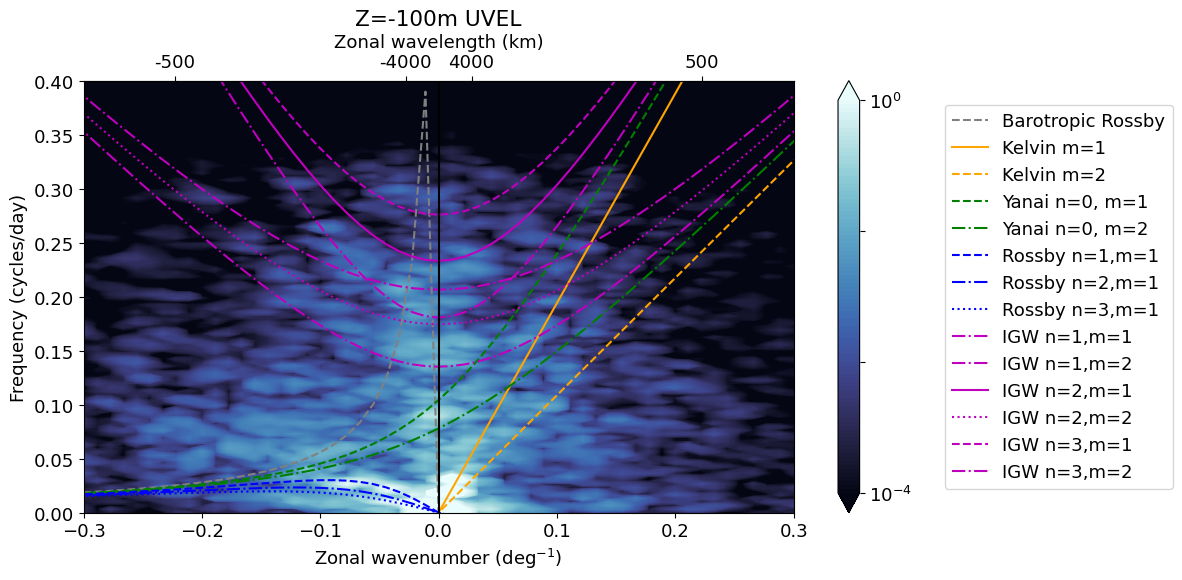

In [388]:
deg2m = 111320      # m per degree at equator
k_rad = 2*np.pi * kx / deg2m  # convert to rad/m
omega_barotropic = -beta * k_rad / (k_rad**2 + 1 * beta / c_barotropic)  # rad/s


fig, ax = plt.subplots(figsize=(12,6))
cf = P_da.plot.contourf(ax=ax,x='kx', y='omega', cmap=cmo.ice,levels=log_levels,extend='both',norm=norm)
cbar = cf.colorbar
cbar.set_ticks(ticks)

ax.set_ylabel('Frequency (cycles/day)')
ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
# Overlay dispersion curves
ax.plot(kx, omega_barotropic*86400/(2*np.pi), color='gray', linestyle='--', label='Barotropic Rossby')
ax.plot(kx, omega_kelvin_fn(k_rad, c1)*86400/(2*np.pi), color='orange', label='Kelvin m=1')
ax.plot(kx, omega_kelvin_fn(k_rad, c2)*86400/(2*np.pi), color='orange', linestyle='--',label='Kelvin m=2')
ax.plot(kx, omega_yanai_east(k_rad, c1, beta)*86400/(2*np.pi), color='green', linestyle='--',label='Yanai n=0, m=1')
ax.plot(kx, omega_yanai_east(k_rad, c2, beta)*86400/(2*np.pi), color='green', linestyle='-.', label='Yanai n=0, m=2')
ax.plot(kx, omega_rossby_fn(k_rad, 1, c1, beta)*86400/(2*np.pi), color='blue', linestyle='--', label='Rossby n=1,m=1')
ax.plot(kx, omega_rossby_fn(k_rad, 2, c1, beta)*86400/(2*np.pi), color='blue', linestyle='-.', label='Rossby n=2,m=1')
ax.plot(kx, omega_rossby_fn(k_rad, 3, c1, beta)*86400/(2*np.pi), color='blue', linestyle=':', label='Rossby n=3,m=1')
ax.plot(kx, omega_IG(k_rad, 1, c1, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=1,m=1')
ax.plot(kx, omega_IG(k_rad, 1, c2, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=1,m=2')
ax.plot(kx, omega_IG(k_rad, 2, c1, beta)*86400/(2*np.pi), color='m', label='IGW n=2,m=1')
ax.plot(kx, omega_IG(k_rad, 2, c2, beta)*86400/(2*np.pi), color='m', linestyle=':', label='IGW n=2,m=2')
ax.plot(kx, omega_IG(k_rad, 3, c1, beta)*86400/(2*np.pi), color='m', linestyle='--', label='IGW n=3,m=1')
ax.plot(kx, omega_IG(k_rad, 3, c2, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=3,m=2')
ax.axvline(0, color='k',label='_nolabel')
ax.legend(bbox_to_anchor=(1.2, 0.5))

# Manually set secondary x-axis ticks
km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
# Set secondary axis manually with fixed tick positions
secax = ax.secondary_xaxis('top')
secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
secax.set_xlabel('Zonal wavelength (km)')
ax.set_title(f'Z={depth}m ' + fig_str)

ax.set_xlim(-0.3,0.3)
ax.set_ylim(0,0.4)

plt.tight_layout()
fig.savefig(foldername + sub_folder + 'k_omega_spectrum_Z' + str(np.abs(depth)) + '_' + fig_str + '.png', dpi=300)

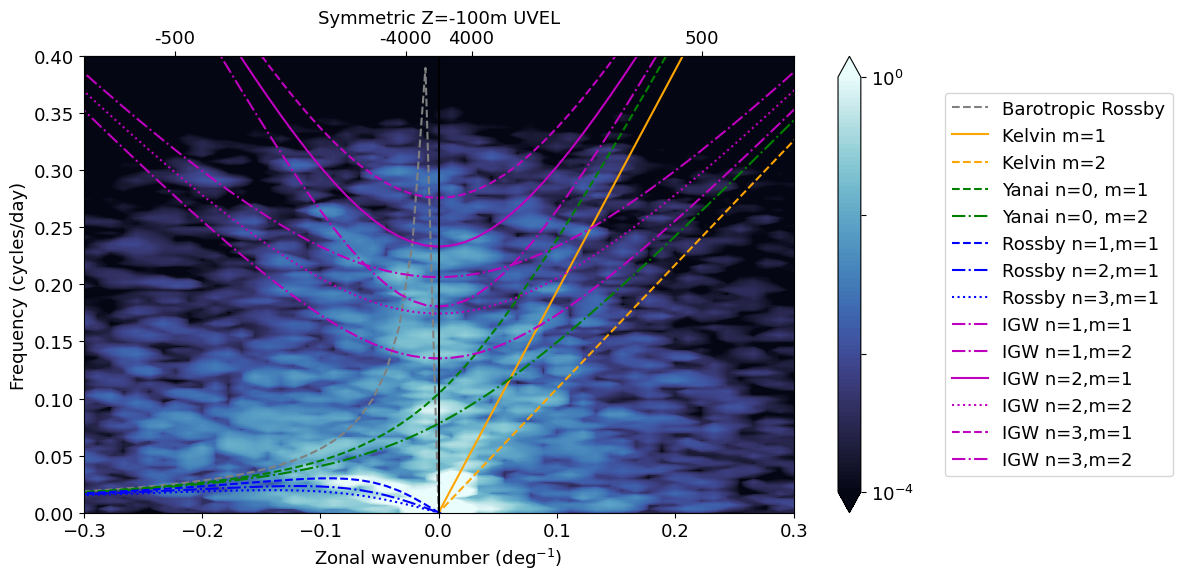

In [392]:
deg2m = 111320      # m per degree at equator
k_rad = 2*np.pi * kx / deg2m  # convert to rad/m
omega_barotropic = -beta * k_rad / (k_rad**2 + 1 * beta / c_barotropic)  # rad/s


fig, ax = plt.subplots(figsize=(12,6))
cf = P_da_sym.plot.contourf(ax=ax,x='kx', y='omega', cmap=cmo.ice,levels=log_levels,extend='both',norm=norm)
cbar = cf.colorbar
cbar.set_ticks(ticks)

ax.set_ylabel('Frequency (cycles/day)')
ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
# Overlay dispersion curves
ax.plot(kx, omega_barotropic*86400/(2*np.pi), color='gray', linestyle='--', label='Barotropic Rossby')
ax.plot(kx, omega_kelvin_fn(k_rad, c1)*86400/(2*np.pi), color='orange', label='Kelvin m=1')
ax.plot(kx, omega_kelvin_fn(k_rad, c2)*86400/(2*np.pi), color='orange', linestyle='--',label='Kelvin m=2')
ax.plot(kx, omega_yanai_east(k_rad, c1, beta)*86400/(2*np.pi), color='green', linestyle='--',label='Yanai n=0, m=1')
ax.plot(kx, omega_yanai_east(k_rad, c2, beta)*86400/(2*np.pi), color='green', linestyle='-.', label='Yanai n=0, m=2')
ax.plot(kx, omega_rossby_fn(k_rad, 1, c1, beta)*86400/(2*np.pi), color='blue', linestyle='--', label='Rossby n=1,m=1')
ax.plot(kx, omega_rossby_fn(k_rad, 2, c1, beta)*86400/(2*np.pi), color='blue', linestyle='-.', label='Rossby n=2,m=1')
ax.plot(kx, omega_rossby_fn(k_rad, 3, c1, beta)*86400/(2*np.pi), color='blue', linestyle=':', label='Rossby n=3,m=1')
ax.plot(kx, omega_IG(k_rad, 1, c1, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=1,m=1')
ax.plot(kx, omega_IG(k_rad, 1, c2, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=1,m=2')
ax.plot(kx, omega_IG(k_rad, 2, c1, beta)*86400/(2*np.pi), color='m', label='IGW n=2,m=1')
ax.plot(kx, omega_IG(k_rad, 2, c2, beta)*86400/(2*np.pi), color='m', linestyle=':', label='IGW n=2,m=2')
ax.plot(kx, omega_IG(k_rad, 3, c1, beta)*86400/(2*np.pi), color='m', linestyle='--', label='IGW n=3,m=1')
ax.plot(kx, omega_IG(k_rad, 3, c2, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=3,m=2')
ax.axvline(0, color='k',label='_nolabel')
ax.legend(bbox_to_anchor=(1.2, 0.5))

# Manually set secondary x-axis ticks
km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
# Set secondary axis manually with fixed tick positions
secax = ax.secondary_xaxis('top')
secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
secax.set_xlabel(f'Symmetric Z={depth}m ' + fig_str)

ax.set_xlim(-0.3,0.3)
ax.set_ylim(0,0.4)

plt.tight_layout()
fig.savefig(foldername + sub_folder + 'k_omega_spectrum_Z' + str(np.abs(depth)) + '_' + fig_str + '_symmetric.png', dpi=300)

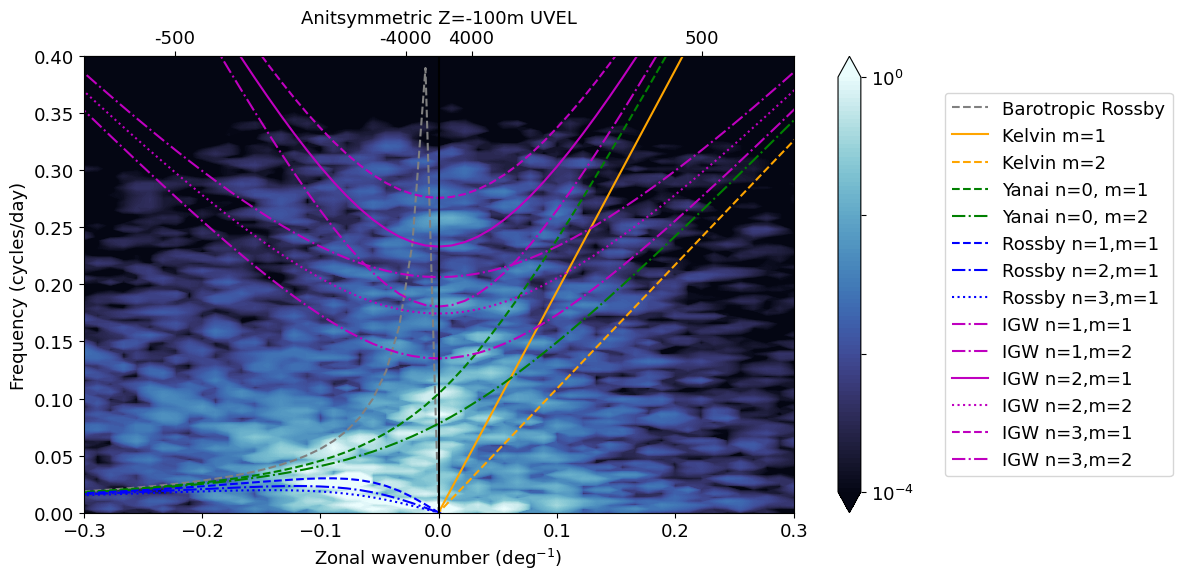

In [393]:
deg2m = 111320      # m per degree at equator
k_rad = 2*np.pi * kx / deg2m  # convert to rad/m
omega_barotropic = -beta * k_rad / (k_rad**2 + 1 * beta / c_barotropic)  # rad/s

fig, ax = plt.subplots(figsize=(12,6))
cf = P_da_anti.plot.contourf(ax=ax,x='kx', y='omega', cmap=cmo.ice,levels=log_levels,extend='both',norm=norm)
cbar = cf.colorbar
cbar.set_ticks(ticks)

ax.set_ylabel('Frequency (cycles/day)')
ax.set_xlabel('Zonal wavenumber (deg$^{-1}$)')
# Overlay dispersion curves
ax.plot(kx, omega_barotropic*86400/(2*np.pi), color='gray', linestyle='--', label='Barotropic Rossby')
ax.plot(kx, omega_kelvin_fn(k_rad, c1)*86400/(2*np.pi), color='orange', label='Kelvin m=1')
ax.plot(kx, omega_kelvin_fn(k_rad, c2)*86400/(2*np.pi), color='orange', linestyle='--',label='Kelvin m=2')
ax.plot(kx, omega_yanai_east(k_rad, c1, beta)*86400/(2*np.pi), color='green', linestyle='--',label='Yanai n=0, m=1')
ax.plot(kx, omega_yanai_east(k_rad, c2, beta)*86400/(2*np.pi), color='green', linestyle='-.', label='Yanai n=0, m=2')
ax.plot(kx, omega_rossby_fn(k_rad, 1, c1, beta)*86400/(2*np.pi), color='blue', linestyle='--', label='Rossby n=1,m=1')
ax.plot(kx, omega_rossby_fn(k_rad, 2, c1, beta)*86400/(2*np.pi), color='blue', linestyle='-.', label='Rossby n=2,m=1')
ax.plot(kx, omega_rossby_fn(k_rad, 3, c1, beta)*86400/(2*np.pi), color='blue', linestyle=':', label='Rossby n=3,m=1')
ax.plot(kx, omega_IG(k_rad, 1, c1, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=1,m=1')
ax.plot(kx, omega_IG(k_rad, 1, c2, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=1,m=2')
ax.plot(kx, omega_IG(k_rad, 2, c1, beta)*86400/(2*np.pi), color='m', label='IGW n=2,m=1')
ax.plot(kx, omega_IG(k_rad, 2, c2, beta)*86400/(2*np.pi), color='m', linestyle=':', label='IGW n=2,m=2')
ax.plot(kx, omega_IG(k_rad, 3, c1, beta)*86400/(2*np.pi), color='m', linestyle='--', label='IGW n=3,m=1')
ax.plot(kx, omega_IG(k_rad, 3, c2, beta)*86400/(2*np.pi), color='m', linestyle='-.', label='IGW n=3,m=2')
ax.axvline(0, color='k',label='_nolabel')
ax.legend(bbox_to_anchor=(1.2, 0.5))

# Manually set secondary x-axis ticks
km_ticks = np.array([-4000, -500, 500, 4000])  # desired top-axis tick labels in km
kdeg_for_ticks = deg2m / (1000 * km_ticks)     # convert km → k_deg
# Set secondary axis manually with fixed tick positions
secax = ax.secondary_xaxis('top')
secax.set_xticks(kdeg_for_ticks)                  # positions in deg^-1
secax.set_xticklabels([str(int(wl)) for wl in km_ticks])  # labels in km
secax.set_xlabel(f'Anitsymmetric Z={depth}m ' + fig_str)

ax.set_xlim(-0.3,0.3)
ax.set_ylim(0,0.4)

plt.tight_layout()
fig.savefig(foldername + sub_folder + 'k_omega_spectrum_Z' + str(np.abs(depth)) + '_' + fig_str + '_antisymmetric.png', dpi=300)

In [391]:
# cluster.close()
# client.shutdown()